# dFBA Batch Culture Simulation
## Aerobic → Anaerobic Respiratory Transition in *E. coli*

**IF3211 Domain-Specific Computation**

---

### Research Question
> *"How does progressive oxygen depletion in a batch culture dynamically regulate the stoichiometric flux boundaries of E. coli metabolism, and what is the implication on total ATP acquisition efficiency versus fermentation byproduct excretion?"*

### Method: Dynamic Flux Balance Analysis (dFBA)
This notebook implements the **Static Optimisation Approach (SOA)** of dFBA:
- **Outer loop**: `scipy.integrate.solve_ivp` (BDF method) integrates ODEs tracking extracellular concentrations
- **Inner loop**: `COBRApy` solves the FBA linear programme at each time step to get instantaneous metabolic fluxes

### Biological Background
| Phase | Condition | ATP yield / glucose | Byproduct |
|-------|-----------|--------------------|-----------|
| Aerobic | O₂ abundant | ~30 ATP | CO₂, H₂O |
| Transition | O₂ limiting | ~5–15 ATP | Acetate |
| Anaerobic | O₂ exhausted | ~2 ATP | Acetate, ethanol |


## 1. Install Dependencies

Run this cell once if packages are not yet installed.

In [7]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'cobra', 'scipy', 'numpy', 'matplotlib'])
print('Dependencies ready.')

Dependencies ready.


## 2. Imports and Logging Setup

In [8]:
import sys, os, logging
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%H:%M:%S'
)

import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
%matplotlib inline

print('Imports OK')

Imports OK


## 3. Simulation Parameters

All parameters are centralised in `src/config.py`. You can override them here for exploration.

In [9]:
from src.config import *

print('=== Simulation Parameters ===')
print(f'  Initial biomass  : {BIOMASS_0} g_DW/L')
print(f'  Initial glucose  : {GLUCOSE_0} mmol/L')
print(f'  Initial oxygen   : {OXYGEN_0} mmol/L')
print(f'  Time span        : {T_START} – {T_END} h')
print(f'  ODE method       : {METHOD}')
print(f'  Vmax glucose     : {VMAX_GLC} mmol/(g·h)')
print(f'  Km glucose       : {KM_GLC} mmol/L')
print(f'  Vmax O2          : {VMAX_O2} mmol/(g·h)')
print(f'  Km O2            : {KM_O2} mmol/L')

=== Simulation Parameters ===
  Initial biomass  : 0.01 g_DW/L
  Initial glucose  : 10.0 mmol/L
  Initial oxygen   : 0.21 mmol/L
  Time span        : 0.0 – 20.0 h
  ODE method       : BDF
  Vmax glucose     : 10.0 mmol/(g·h)
  Km glucose       : 0.015 mmol/L
  Vmax O2          : 15.0 mmol/(g·h)
  Km O2            : 0.001 mmol/L


## 4. Load the *E. coli* Metabolic Model

The **textbook** model (E. coli core, Orth et al. 2010) contains:
- 72 metabolites
- 95 reactions (glycolysis, TCA, ETC, fermentation branches)
- Objective: maximise biomass production (BIOMASS_Ecoli_core_w_GAM)

In [10]:
from src.model_loader import load_ecoli_model

model = load_ecoli_model()

print(f'Model: {model.id}')
print(f'Reactions : {len(model.reactions)}')
print(f'Metabolites: {len(model.metabolites)}')
print(f'Objective : {model.objective}')

# Quick sanity check — aerobic FBA
with model:
    sol = model.optimize()
    print(f'\nAerobic FBA (unconstrained) growth rate: {sol.objective_value:.4f} h⁻¹')

18:00:32  INFO      Loading E. coli core ('textbook') model via COBRApy …
18:00:32  INFO      Attempting to fetch 'textbook' from the Cobrapy repository.
18:00:32  INFO      The current solver interface glpk doesn't support setting the optimality tolerance.
18:00:32  INFO      Model loaded: 95 reactions, 72 metabolites


Model: e_coli_core
Reactions : 95
Metabolites: 72
Objective : Maximize
1.0*Biomass_Ecoli_core - 1.0*Biomass_Ecoli_core_reverse_2cdba

Aerobic FBA (unconstrained) growth rate: 34.0473 h⁻¹


## 5. Demonstrate Michaelis-Menten Kinetic Bounds

The uptake rate of glucose and O₂ follows saturable kinetics:

$$v = \frac{V_{max} \cdot [S]}{K_m + [S]}$$

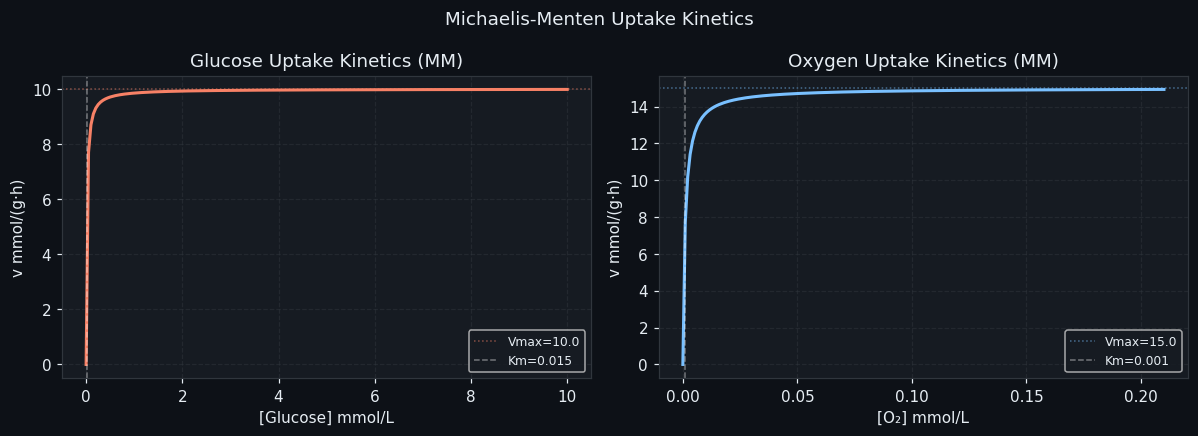

In [11]:
import matplotlib.pyplot as plt

s_glc = np.linspace(0, 10, 200)
s_o2  = np.linspace(0, 0.21, 200)

v_glc = VMAX_GLC * s_glc / (KM_GLC + s_glc)
v_o2  = VMAX_O2  * s_o2  / (KM_O2  + s_o2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), facecolor='#0d1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#e6edf3')
    ax.xaxis.label.set_color('#e6edf3')
    ax.yaxis.label.set_color('#e6edf3')
    ax.title.set_color('#e6edf3')
    ax.grid(True, color='#30363d', linestyle='--', alpha=0.5)
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

ax1.plot(s_glc, v_glc, color='#f78166', lw=2)
ax1.axhline(VMAX_GLC, color='#f78166', lw=1, ls=':', alpha=0.5, label=f'Vmax={VMAX_GLC}')
ax1.axvline(KM_GLC, color='white', lw=1, ls='--', alpha=0.4, label=f'Km={KM_GLC}')
ax1.set_title('Glucose Uptake Kinetics (MM)')
ax1.set_xlabel('[Glucose] mmol/L'); ax1.set_ylabel('v mmol/(g·h)')
ax1.legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=8)

ax2.plot(s_o2, v_o2, color='#79c0ff', lw=2)
ax2.axhline(VMAX_O2, color='#79c0ff', lw=1, ls=':', alpha=0.5, label=f'Vmax={VMAX_O2}')
ax2.axvline(KM_O2,  color='white', lw=1, ls='--', alpha=0.4, label=f'Km={KM_O2}')
ax2.set_title('Oxygen Uptake Kinetics (MM)')
ax2.set_xlabel('[O₂] mmol/L'); ax2.set_ylabel('v mmol/(g·h)')
ax2.legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=8)

plt.suptitle('Michaelis-Menten Uptake Kinetics', color='#e6edf3', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Run the dFBA Simulation

The `run_dfba()` function couples:
- `dynamic_system()` — ODE RHS that calls FBA at each step
- `infeasible_event()` — stops integration when substrates are exhausted

In [12]:
from src.solver import run_dfba
import time

t0 = time.time()
solution = run_dfba(model)
print(f'\nSimulation completed in {time.time()-t0:.1f} s')
print(f'Time steps returned : {len(solution.t)}')
print(f'Final biomass       : {solution.y[0,-1]:.4f} g_DW/L')
print(f'Final glucose       : {solution.y[1,-1]:.4f} mmol/L')
print(f'Final oxygen        : {solution.y[2,-1]:.6f} mmol/L')
print(f'Final acetate       : {solution.y[3,-1]:.4f} mmol/L')
if solution.t_events and len(solution.t_events[0]) > 0:
    print(f'Infeasibility event : t = {solution.t_events[0][0]:.3f} h')

18:00:32  INFO      ============================================================
18:00:32  INFO      Starting dFBA simulation
18:00:32  INFO        Method : BDF | t_span : (0.0, 20.0) h
18:00:32  INFO        y0 : X=0.0100 | Glc=10.00 | O2=0.2100 | Ace=0.00
18:00:32  INFO      ============================================================
c:\Users\thema\Informatics\Language\Python\dFBA-Batch-Culture-Simulation\.venv\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
18:00:33  INFO      Oxygen transition at t = 1.0267 h
18:00:33  INFO      Status: The solver successfully reached the end of the integration interval. | Steps: 500
18:00:33  INFO      ============================================================



Simulation completed in 0.7 s
Time steps returned : 500
Final biomass       : 0.2276 g_DW/L
Final glucose       : 0.0066 mmol/L
Final oxygen        : -0.000000 mmol/L
Final acetate       : 8.4858 mmol/L


## 7. Visualise Results

6-panel figure showing all state variables and derived quantities.

18:00:34  INFO      Plot saved -> c:\Users\thema\Informatics\Language\Python\dFBA-Batch-Culture-Simulation\notebooks\results\dfba_results.png


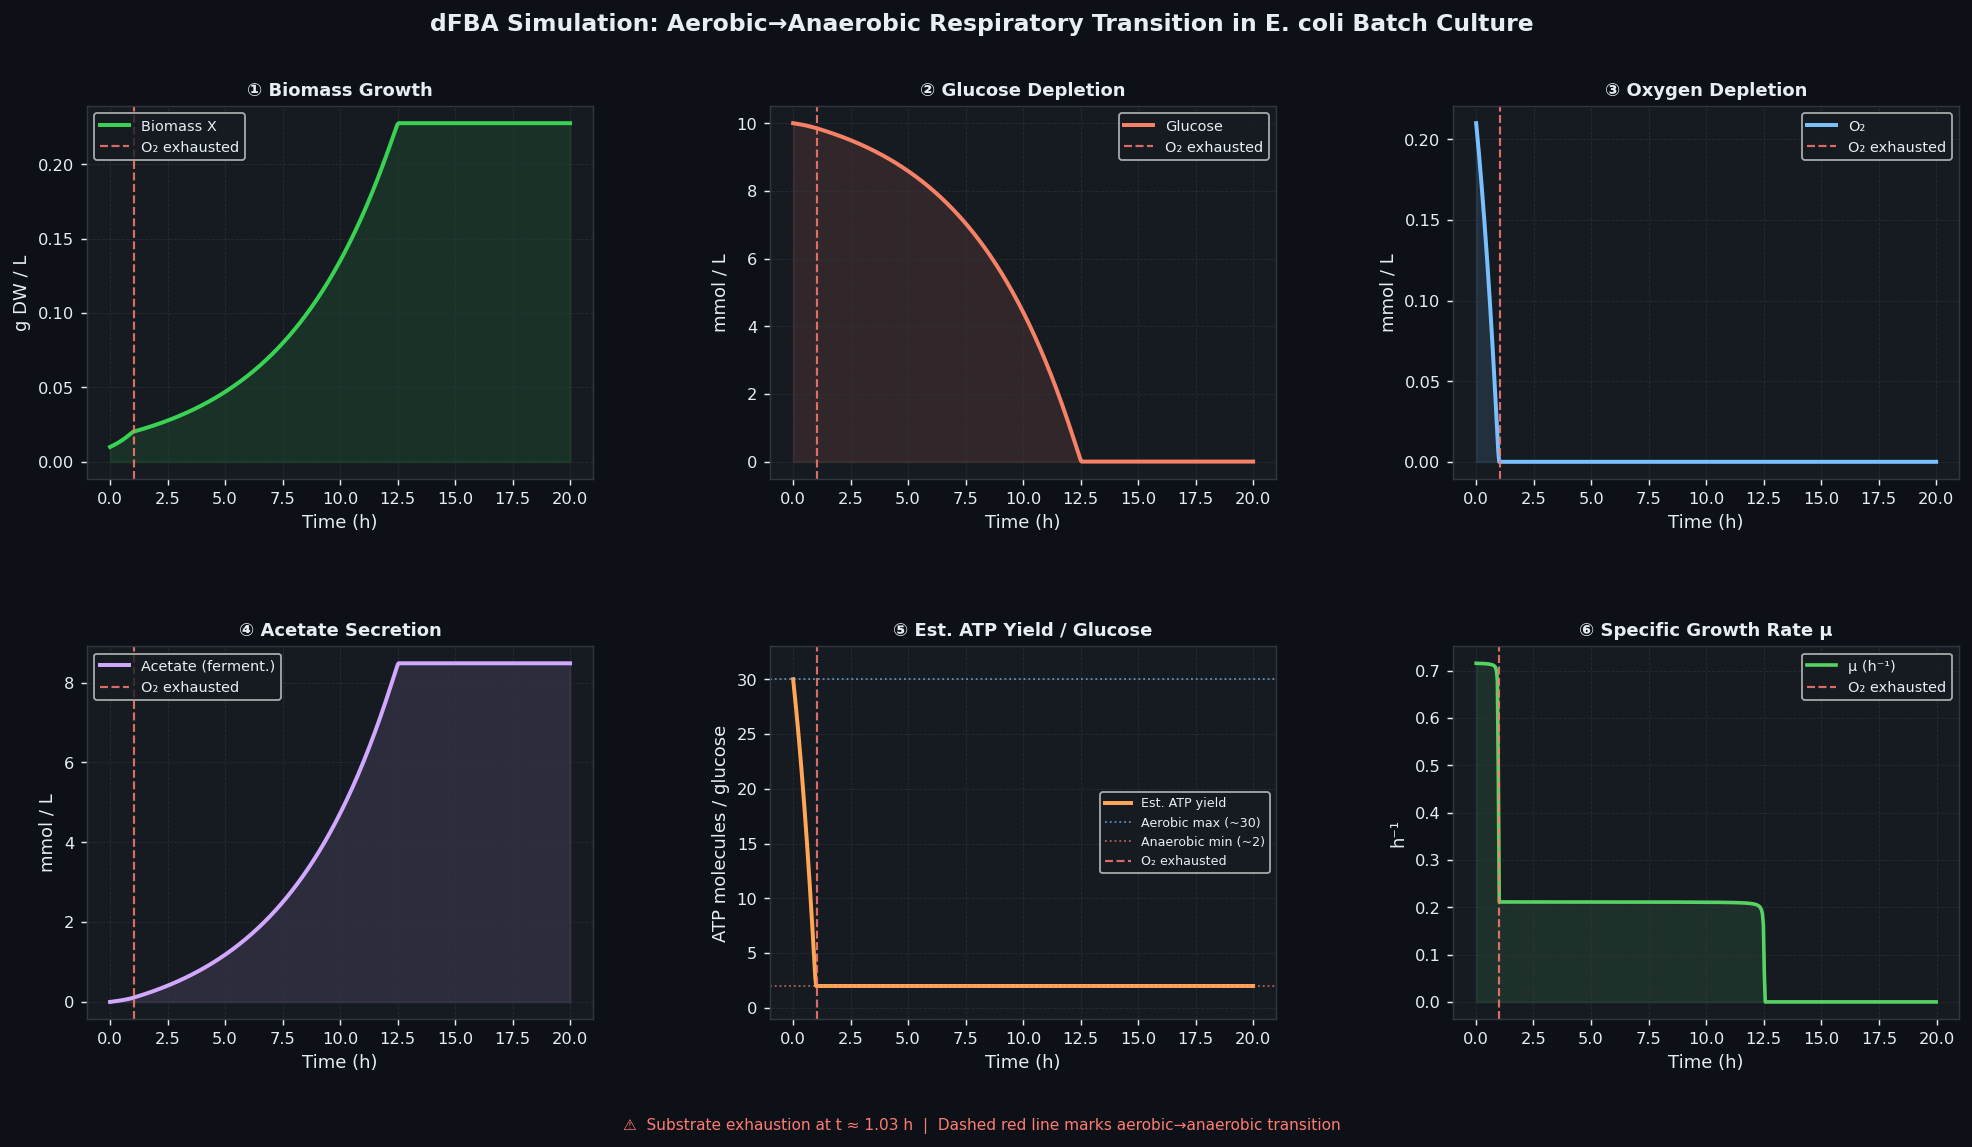

'results\\dfba_results.png'

In [13]:
from src.visualization import plot_results

# Save PNG + display inline
plot_results(solution, save=True, show=True)

## 8. Analysis: ATP Yield Transition

Extract and plot the critical transition from aerobic to anaerobic metabolism.

In [14]:
t   = solution.t
X   = solution.y[0]
Glc = solution.y[1]
O2  = solution.y[2]
Ace = solution.y[3]

# Estimated ATP yield based on fractional O2
atp = ATP_ANAEROBIC + (ATP_AEROBIC - ATP_ANAEROBIC) * np.clip(O2 / OXYGEN_0, 0, 1)

# Find approximate transition point (O2 < 5% of initial)
threshold = 0.05 * OXYGEN_0
transition_idx = np.argmax(O2 < threshold) if np.any(O2 < threshold) else len(t)-1
t_transition = t[transition_idx]

print(f'O2 transition threshold : {threshold:.4f} mmol/L')
print(f'Transition time         : {t_transition:.3f} h')
print(f'Biomass at transition   : {X[transition_idx]:.4f} g_DW/L')
print(f'Est. ATP at t=0         : {atp[0]:.1f} ATP/glucose')
print(f'Est. ATP at transition  : {atp[transition_idx]:.1f} ATP/glucose')
print(f'Est. ATP at end         : {atp[-1]:.1f} ATP/glucose')
print(f'Acetate at end          : {Ace[-1]:.4f} mmol/L')
print()
print('→ The simulation confirms the shift from high-yield aerobic')
print('  respiration to low-yield fermentation as O₂ is depleted.')

O2 transition threshold : 0.0105 mmol/L
Transition time         : 0.962 h
Biomass at transition   : 0.0198 g_DW/L
Est. ATP at t=0         : 30.0 ATP/glucose
Est. ATP at transition  : 2.8 ATP/glucose
Est. ATP at end         : 2.0 ATP/glucose
Acetate at end          : 8.4858 mmol/L

→ The simulation confirms the shift from high-yield aerobic
  respiration to low-yield fermentation as O₂ is depleted.


## 9. Parameter Sensitivity Experiment

Run two scenarios with different initial O₂ to observe how oxygen availability affects the transition.

18:00:34  INFO      ============================================================
18:00:34  INFO      Starting dFBA simulation
18:00:34  INFO        Method : BDF | t_span : (0.0, 20.0) h
18:00:34  INFO        y0 : X=0.0100 | Glc=10.00 | O2=0.5000 | Ace=0.00
18:00:34  INFO      ============================================================
18:00:35  INFO      Oxygen transition at t = 1.7386 h
18:00:35  INFO      Status: The solver successfully reached the end of the integration interval. | Steps: 500
18:00:35  INFO      ============================================================
18:00:35  INFO      ============================================================
18:00:35  INFO      Starting dFBA simulation
18:00:35  INFO        Method : BDF | t_span : (0.0, 20.0) h
18:00:35  INFO        y0 : X=0.0100 | Glc=10.00 | O2=0.2100 | Ace=0.00
18:00:35  INFO      ============================================================
18:00:36  INFO      Oxygen transition at t = 1.0267 h
18:00:36  INFO      Statu

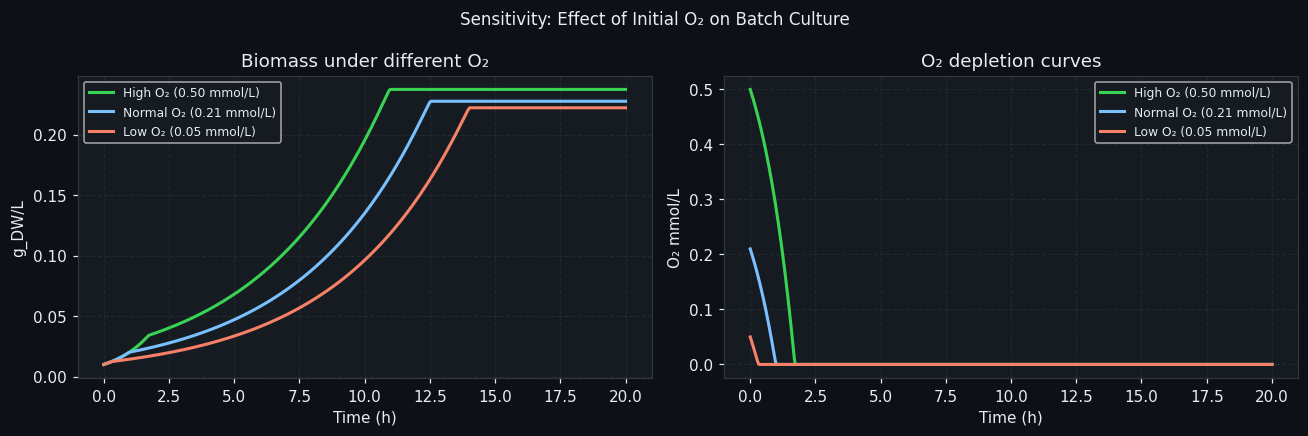

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0d1117')
colours_exp = ['#39d353', '#f78166', '#79c0ff']

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#e6edf3')
    ax.xaxis.label.set_color('#e6edf3')
    ax.yaxis.label.set_color('#e6edf3')
    ax.title.set_color('#e6edf3')
    ax.grid(True, color='#30363d', linestyle='--', alpha=0.5)
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

scenarios = [
    ('High O₂ (0.50 mmol/L)', [0.01, 10.0, 0.50, 0.0], '#39d353'),
    ('Normal O₂ (0.21 mmol/L)', [0.01, 10.0, 0.21, 0.0], '#79c0ff'),
    ('Low O₂ (0.05 mmol/L)', [0.01, 10.0, 0.05, 0.0], '#f78166'),
]

for label, y0_s, clr in scenarios:
    sol_s = run_dfba(model, y0=y0_s)
    axes[0].plot(sol_s.t, sol_s.y[0], color=clr, lw=2, label=label)
    axes[1].plot(sol_s.t, sol_s.y[2], color=clr, lw=2, label=label)

axes[0].set_title('Biomass under different O₂'); axes[0].set_xlabel('Time (h)'); axes[0].set_ylabel('g_DW/L')
axes[1].set_title('O₂ depletion curves');        axes[1].set_xlabel('Time (h)'); axes[1].set_ylabel('O₂ mmol/L')

for ax in axes:
    ax.legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=8)

plt.suptitle('Sensitivity: Effect of Initial O₂ on Batch Culture', color='#e6edf3', fontsize=11)
plt.tight_layout()
plt.show()

## 10. Conclusion

This dFBA simulation demonstrates:

1. **Aerobic phase**: Rapid exponential biomass growth while glucose and O₂ are available. ATP yield ≈ 30 molecules/glucose via oxidative phosphorylation.

2. **Transition phase**: As O₂ depletes, the metabolic model shifts flux toward fermentation pathways. Acetate secretion begins, ATP yield drops.

3. **Anaerobic / starvation phase**: When O₂ → 0, the FBA problem becomes infeasible (no terminal electron acceptor). Growth ceases. ATP yield ≈ 2 molecules/glucose (glycolysis only).

4. **Parameter sensitivity**: Higher initial O₂ prolongs the aerobic phase and allows greater biomass accumulation before the metabolic switch.

---

### References
1. COBRApy dFBA Tutorial — https://cobrapy.readthedocs.io/en/latest/dfba.html
2. Orth, J.D. et al. (2010). *What is flux balance analysis?* Nature Biotechnology.
3. Mahadevan, R. et al. (2002). *Dynamic FBA of diauxic growth in E. coli.* Biophysical Journal.